In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)

In [21]:
# Load optimized data
with open('../../data/train_test_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print("="*80)
print("DATASET INFO")
print("="*80)
print(f"Total records: {len(df):,}")
print(f"Train records: {(df['_source'] == 'train').sum():,}")
print(f"Test records: {(df['_source'] == 'test').sum():,}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nFraud rate (train): {df[df['_source']=='train']['isFraud'].mean()*100:.2f}%")

DATASET INFO
Total records: 1,097,231
Train records: 590,540
Test records: 506,691
Memory: 1569.98 MB

Fraud rate (train): 3.50%


In [22]:
# ==================== TEMPORAL FEATURES ====================
# Create week_num and month_num for aggregations (will be dropped later)

df['week_num'] = (df['TransactionDT'] // 604800).astype('int16')  # 1 week = 604800 seconds
df['month_num'] = (df['week_num'] // 4).astype('int16')  # ~4 weeks = 1 month

print("="*80)
print("TEMPORAL FEATURES CREATED")
print("="*80)
print(f"✓ Week range: {df['week_num'].min()} to {df['week_num'].max()}")
print(f"✓ Month range: {df['month_num'].min()} to {df['month_num'].max()}")
print(f"✓ Total weeks: {df['week_num'].nunique()}")
print(f"✓ Total months: {df['month_num'].nunique()}")
print(f"\nNote: These are temporary columns for aggregation, will be removed at cleanup step")
print("="*80)

TEMPORAL FEATURES CREATED
✓ Week range: 0 to 56
✓ Month range: 0 to 14
✓ Total weeks: 54
✓ Total months: 15

Note: These are temporary columns for aggregation, will be removed at cleanup step


In [23]:
# ==================== UID (User ID) & USER ANCHOR ====================

print("="*80)
print("CORE USER IDENTIFICATION FEATURES")
print("="*80)

# 1. UID: card1 + addr1 kombinasyonu (04'teki en başarılı approach)
df['uid_card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
print(f"\n✓ UID created: {df['uid_card1_addr1'].nunique():,} unique users")

# 2. USER ANCHOR D1 - En önemli feature (12.90% importance)
# TransactionDT - D1*86400 gives consistent anchor per user
df['user_anchor_D1'] = df['TransactionDT'] - (df['D1'] * 86400)
print(f"✓ User Anchor D1 created: {df['user_anchor_D1'].nunique():,} unique anchors")
print(f"  - Missing: {df['user_anchor_D1'].isna().sum():,} ({df['user_anchor_D1'].isna().mean()*100:.1f}%)")

print(f"\n{'='*80}")
print(f"Dataset shape: {df.shape}")
print(f"{'='*80}")

CORE USER IDENTIFICATION FEATURES

✓ UID created: 51,664 unique users
✓ User Anchor D1 created: 1,071,580 unique anchors
  - Missing: 7,300 (0.7%)

Dataset shape: (1097231, 477)


In [ ]:
# ==================== UID BEHAVIORAL FEATURES ====================
# 04'te Top 20'de olan: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_txn_count, etc.
#
# ⚠️ HIGH CORRELATION WARNING:
# Aşağıdaki feature'lar yüksek korelasyon (|r| > 0.8) nedeniyle DROP edilecek:
#   - uid_txn_count       (corr=0.989 with uid_total_amt)  → uid_total_amt KALACAK
#   - uid_month_txn_count (corr=0.945 with uid_total_amt)  → uid_total_amt KALACAK  
#   - uid_week_avg_amt    (corr=0.833 with uid_month_avg_amt) → uid_month_avg_amt KALACAK
#   - amt_vs_uid_week_avg (corr=0.894 with amt_vs_uid_month_avg) → amt_vs_uid_month_avg KALACAK
#   - amt_vs_uid_avg      (corr=0.873 with amt_vs_uid_month_avg) → amt_vs_uid_month_avg KALACAK
# Feature selection hücresinde otomatik olarak drop edilecekler.

print("="*80)
print("UID BEHAVIORAL FEATURES (Top Priority - Based on 04 Model)")
print("="*80)

# 1. GENERAL STATISTICS
print("\n1. General UID statistics...")
uid_general_agg = df.groupby('uid_card1_addr1').agg({
    'TransactionAmt': ['mean', 'std', 'max', 'min', 'sum', 'count']
})

uid_general_agg.columns = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 
                            'uid_min_amt', 'uid_total_amt', 'uid_txn_count']
uid_general_agg = uid_general_agg.reset_index()

df = df.merge(uid_general_agg, on='uid_card1_addr1', how='left')
print(f"   ✓ Added: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_total_amt")
print(f"   ⚠️ uid_txn_count → HIGH CORR with uid_total_amt (0.989), will be DROPPED")

# 2. WEEKLY STATISTICS
print("\n2. Weekly UID statistics...")
uid_weekly_agg = df.groupby(['uid_card1_addr1', 'week_num']).agg({
    'TransactionAmt': ['mean', 'count']
})

uid_weekly_agg.columns = ['uid_week_avg_amt', 'uid_week_txn_count']
uid_weekly_agg = uid_weekly_agg.reset_index()

df = df.merge(uid_weekly_agg, on=['uid_card1_addr1', 'week_num'], how='left')
print(f"   ✓ Added: uid_week_txn_count")
print(f"   ⚠️ uid_week_avg_amt → HIGH CORR with uid_month_avg_amt (0.833), will be DROPPED")

# 3. MONTHLY STATISTICS
print("\n3. Monthly UID statistics...")
uid_monthly_agg = df.groupby(['uid_card1_addr1', 'month_num']).agg({
    'TransactionAmt': ['mean', 'count']
})

uid_monthly_agg.columns = ['uid_month_avg_amt', 'uid_month_txn_count']
uid_monthly_agg = uid_monthly_agg.reset_index()

df = df.merge(uid_monthly_agg, on=['uid_card1_addr1', 'month_num'], how='left')
print(f"   ✓ Added: uid_month_avg_amt (KEPT - higher importance)")
print(f"   ⚠️ uid_month_txn_count → HIGH CORR with uid_total_amt (0.945), will be DROPPED")

# 4. ANOMALY DETECTION RATIOS
print("\n4. UID anomaly detection ratios...")
df['amt_vs_uid_avg'] = df['TransactionAmt'] / (df['uid_avg_amt'] + 1)
df['amt_vs_uid_week_avg'] = df['TransactionAmt'] / (df['uid_week_avg_amt'] + 1)
df['amt_vs_uid_month_avg'] = df['TransactionAmt'] / (df['uid_month_avg_amt'] + 1)
print(f"   ✓ Added: amt_vs_uid_month_avg (KEPT - higher importance)")
print(f"   ⚠️ amt_vs_uid_avg → HIGH CORR with amt_vs_uid_month_avg (0.873), will be DROPPED")
print(f"   ⚠️ amt_vs_uid_week_avg → HIGH CORR with amt_vs_uid_month_avg (0.894), will be DROPPED")

print(f"\n{'='*80}")
print(f"UID features created. Shape: {df.shape}")
print(f"⚠️ Note: 5 high-corr UID features will be dropped in Feature Selection step")
print(f"{'='*80}")

UID BEHAVIORAL FEATURES (Top Priority - Based on 04 Model)

1. General UID statistics...
   ✓ Added: uid_avg_amt (2.71% imp), uid_max_amt (2.65%), uid_min_amt (2.61%), uid_std_amt (2.07%), uid_txn_count (2.06%)

2. Weekly UID statistics...
   ✓ Added: uid_week_avg_amt, uid_week_txn_count (2.55% imp)

3. Monthly UID statistics...
   ✓ Added: uid_month_avg_amt (2.39% imp), uid_month_txn_count (2.30% imp)

4. UID anomaly detection ratios...
   ✓ Added: amt vs avg ratios (anomaly detection)

UID features created. Shape: (1097231, 490)


In [ ]:
# ==================== CARD1 STATISTICS ====================
# 04'te önemli çıkan: amt_mean, amt_max, amt_std, n_devices
#
# ⚠️ HIGH CORRELATION WARNING:
#   - amt_std (corr=0.836 with amt_mean) → amt_mean KALACAK (higher importance: 170 vs 112)

print("="*80)
print("CARD1 AGGREGATED STATISTICS")
print("="*80)

card1_agg = df.groupby('card1').agg({
    'TransactionAmt': ['mean', 'std', 'max'],
    'addr1': 'nunique',
    'DeviceInfo': 'nunique'
}).reset_index()

card1_agg.columns = ['card1', 'amt_mean', 'amt_std', 'amt_max', 'n_addr', 'n_devices']

df = df.merge(card1_agg, on='card1', how='left')

print(f"\n✓ Card1 statistics added:")
print(f"  - amt_mean (KEPT - higher importance)")
print(f"  - amt_max")
print(f"  - n_addr: unique addresses per card")
print(f"  - n_devices")
print(f"  ⚠️ amt_std → HIGH CORR with amt_mean (0.836), will be DROPPED")

print(f"\n{'='*80}")
print(f"Dataset shape: {df.shape}")
print(f"{'='*80}")

CARD1 AGGREGATED STATISTICS

✓ Card1 statistics added:
  - amt_mean (5.61% importance in 04)
  - amt_std (2.49% importance)
  - amt_max (2.69% importance)
  - n_addr: unique addresses per card
  - n_devices (2.07% importance)

Dataset shape: (1097231, 495)


In [26]:
# ==================== PSYCHOLOGICAL AMOUNT FEATURES ====================
# İnsanlar belirli sayıları tercih eder: yuvarlak (100, 500), psikolojik (99, 199)
# Fraud botları genellikle random sayılar üretir

print("="*80)
print("PSYCHOLOGICAL AMOUNT ANALYSIS")
print("="*80)

def classify_amount_type(amount):
    """
    TransactionAmt'yi 3 kategoriye ayır (dolar ve cent kısmı birlikte):
    - 'round': Yuvarlak sayılar (10.00, 50.00, 100.00, 500.00)
    - 'psychological': Psikolojik sayılar (9.99, 49.99, 99.95, 199.99)
    - 'random': Diğer sayılar (gerçek işlemler: 123.47, 87.32)
    """
    # Tam sayı ve cent kısmı
    int_part = int(amount)
    cents = round((amount - int_part) * 100)  # Cent kısmı (0-99)
    
    # 1. YUVARLAK SAYILAR (tam dolar, cent = 00)
    if cents == 0:
        # 100.00, 200.00, 500.00, 1000.00
        if int_part % 100 == 0 or int_part % 50 == 0 or int_part % 10 == 0:
            return 'round'
    
    # 2. PSİKOLOJİK SAYILAR (cent kısmı önemli)
    # 9.99, 19.99, 49.99, 99.99, 199.99, 499.99
    if cents == 99:
        return 'psychological'
    
    # 9.95, 19.95, 49.95, 99.95, 199.95
    if cents == 95:
        return 'psychological'
    
    # 9.90, 19.90, 49.90 (cent = 90)
    if cents == 90:
        last_digit = int_part % 10
        if last_digit == 9:  # 9.90, 19.90, 29.90
            return 'psychological'
    
    # Tam sayı kısmı psikolojik ve cent == 0: 99.00, 49.00
    if cents == 0:
        last_digit = int_part % 10
        if last_digit == 9 or last_digit == 5:
            return 'psychological'
    
    # 3. DİĞER HER ŞEY RANDOM
    return 'random'

# Feature oluştur
df['amt_type'] = df['TransactionAmt'].apply(classify_amount_type)

# İstatistikler
print(f"\n📊 Amount Type Distribution:")
amt_dist = df['amt_type'].value_counts()
for amt_type, count in amt_dist.items():
    pct = count / len(df) * 100
    print(f"  - {amt_type:<15}: {count:>8,} ({pct:>5.1f}%)")

# Train data için fraud rate analizi
if 'isFraud' in df.columns:
    train_mask = df['_source'] == 'train'
    print(f"\n🔍 Fraud Rate by Amount Type (Train Data):")
    
    for amt_type in ['round', 'psychological', 'random']:
        mask = train_mask & (df['amt_type'] == amt_type)
        if mask.sum() > 0:
            fraud_rate = df[mask]['isFraud'].mean() * 100
            count = mask.sum()
            print(f"  - {amt_type:<15}: {fraud_rate:>5.2f}% fraud ({count:,} txns)")

# Ek binary features
df['is_round_amount'] = (df['amt_type'] == 'round').astype('int8')
df['is_psych_amount'] = (df['amt_type'] == 'psychological').astype('int8')
df['is_random_amount'] = (df['amt_type'] == 'random').astype('int8')

# Cent analizi (decimal kısım)
df['amt_cents'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 100).round().astype('int16')
df['has_cents'] = (df['amt_cents'] > 0).astype('int8')  # Cent var mı?
df['is_99_cents'] = (df['amt_cents'] == 99).astype('int8')  # .99 ile mi bitiyor?
df['is_95_cents'] = (df['amt_cents'] == 95).astype('int8')  # .95 ile mi bitiyor?
df['is_round_cents'] = (df['amt_cents'] % 10 == 0).astype('int8')  # .00, .10, .20, ... gibi

print(f"\n✓ Created features:")
print(f"  - amt_type (categorical: round/psychological/random)")
print(f"  - is_round_amount (binary)")
print(f"  - is_psych_amount (binary)")
print(f"  - is_random_amount (binary)")
print(f"  - amt_cents (0-99)")
print(f"  - has_cents (binary)")
print(f"  - is_99_cents (binary)")
print(f"  - is_95_cents (binary)")
print(f"  - is_round_cents (binary)")

print(f"\n{'='*80}")
print(f"Dataset shape: {df.shape}")
print(f"{'='*80}")

PSYCHOLOGICAL AMOUNT ANALYSIS

📊 Amount Type Distribution:
  - psychological  :  522,060 ( 47.6%)
  - random         :  422,554 ( 38.5%)
  - round          :  152,617 ( 13.9%)

🔍 Fraud Rate by Amount Type (Train Data):
  - round          :  4.45% fraud (81,235 txns)
  - psychological  :  1.58% fraud (281,107 txns)
  - random         :  5.53% fraud (228,198 txns)

✓ Created features:
  - amt_type (categorical: round/psychological/random)
  - is_round_amount (binary)
  - is_psych_amount (binary)
  - is_random_amount (binary)
  - amt_cents (0-99)
  - has_cents (binary)
  - is_99_cents (binary)
  - is_95_cents (binary)
  - is_round_cents (binary)

Dataset shape: (1097231, 504)


In [27]:
# ==================== SMART MISSING VALUE FILLING ====================

print("\nFilling missing values with smart strategy...\n")

# Strategy:
# - Aggregation features (avg, std, count) → 0 (no history)
# - Ratio features (amt vs avg) → 1.0 (neutral)

# Email+Address features
ea_agg_features = ['ea_avg_amt', 'ea_std_amt', 'ea_max_amt', 'ea_min_amt', 
                   'ea_total_amt', 'ea_txn_count', 'ea_week_avg_amt', 
                   'ea_week_txn_count', 'ea_month_avg_amt', 'ea_month_txn_count']

ea_ratio_features = ['ea_amt_vs_avg', 'ea_amt_vs_week_avg', 'ea_amt_vs_month_avg']

for col in ea_agg_features:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        
for col in ea_ratio_features:
    if col in df.columns:
        df[col] = df[col].fillna(1.0)

print("✓ Email+Address features filled")

# Device+Address features
da_agg_features = ['da_avg_amt', 'da_std_amt', 'da_max_amt', 'da_min_amt', 
                   'da_txn_count', 'da_week_avg_amt', 'da_week_txn_count']

da_ratio_features = ['da_amt_vs_avg', 'da_amt_vs_week_avg']

for col in da_agg_features:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        
for col in da_ratio_features:
    if col in df.columns:
        df[col] = df[col].fillna(1.0)

print("✓ Device+Address features filled")

# Card Family features
cf_agg_features = ['cf_avg_amt', 'cf_std_amt', 'cf_txn_count', 
                   'cf_unique_cards', 'cf_week_avg_amt']

cf_ratio_features = ['cf_amt_vs_avg']

for col in cf_agg_features:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        
for col in cf_ratio_features:
    if col in df.columns:
        df[col] = df[col].fillna(1.0)

print("✓ Card Family features filled")

print(f"\n{'='*80}")
print("Missing value handling completed!")
print(f"{'='*80}")


Filling missing values with smart strategy...

✓ Email+Address features filled
✓ Device+Address features filled
✓ Card Family features filled

Missing value handling completed!


In [28]:
# ==================== CLEANUP ====================

# Geçici zaman feature'larını sil
temp_cols = ['week_num', 'month_num']
df = df.drop(columns=temp_cols, errors='ignore')

print("✓ Temporary columns removed: week_num, month_num")
print(f"\nFinal dataset shape: {df.shape}")

✓ Temporary columns removed: week_num, month_num

Final dataset shape: (1097231, 502)


In [29]:
# ==================== FRAUD CORRELATION ANALYSIS ====================

if 'isFraud' in df.columns:
    train_data = df[df['_source'] == 'train'].copy()
    
    # Define all new features created in this notebook
    all_new_features = [
        # UID features
        'uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 'uid_min_amt', 'uid_total_amt', 'uid_txn_count',
        'uid_week_avg_amt', 'uid_week_txn_count', 'uid_month_avg_amt', 'uid_month_txn_count',
        'amt_vs_uid_avg', 'amt_vs_uid_week_avg', 'amt_vs_uid_month_avg',
        # Card1 features
        'amt_mean', 'amt_std', 'amt_max', 'n_addr', 'n_devices',
        # Psychological amount features
        'is_round_amount', 'is_psych_amount', 'is_random_amount',
        'amt_cents', 'has_cents', 'is_99_cents', 'is_95_cents', 'is_round_cents',
        # User anchor
        'user_anchor_D1'
    ]
    
    # Calculate correlations for new features
    new_numeric_features = [col for col in all_new_features 
                           if col in train_data.columns 
                           and train_data[col].dtype in ['float64', 'float32', 'int64', 'int32', 'int16', 'int8']]
    
    correlations = train_data[new_numeric_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
    correlations = correlations.abs().sort_values(ascending=False)
    
    print("\n" + "="*80)
    print("TOP 20 FEATURES BY FRAUD CORRELATION")
    print("="*80)
    
    for idx, (feat, corr) in enumerate(correlations.head(20).items(), 1):
        print(f"{idx:2d}. {feat:<40} : {corr:.4f}")
    
    print(f"\n{'='*80}")


TOP 20 FEATURES BY FRAUD CORRELATION
 1. is_psych_amount                          : 0.0998
 2. is_95_cents                              : 0.0946
 3. is_random_amount                         : 0.0878
 4. n_devices                                : 0.0724
 5. amt_cents                                : 0.0488
 6. uid_avg_amt                              : 0.0463
 7. uid_month_avg_amt                        : 0.0428
 8. uid_week_avg_amt                         : 0.0395
 9. uid_std_amt                              : 0.0303
10. amt_std                                  : 0.0300
11. amt_mean                                 : 0.0256
12. amt_vs_uid_avg                           : 0.0243
13. uid_min_amt                              : 0.0230
14. amt_max                                  : 0.0225
15. is_round_amount                          : 0.0206
16. amt_vs_uid_month_avg                     : 0.0192
17. amt_vs_uid_week_avg                      : 0.0188
18. uid_max_amt                             

In [30]:
# ==================== TRAIN/TEST SPLIT ====================

train_df = df[df['_source'] == 'train'].copy()
test_df = df[df['_source'] == 'test'].copy()

print("="*80)
print("TRAIN/TEST SPLIT")
print("="*80)
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train fraud rate: {train_df['isFraud'].mean()*100:.2f}%")

# Drop _source column
train_df = train_df.drop('_source', axis=1)
test_df = test_df.drop('_source', axis=1)

print(f"\n✓ _source column dropped")
print(f"Train final shape: {train_df.shape}")

TRAIN/TEST SPLIT
Train shape: (590540, 502)
Test shape: (506691, 502)
Train fraud rate: 3.50%

✓ _source column dropped
Train final shape: (590540, 501)


In [ ]:
# ==================== FEATURE SELECTION ====================

# Get all column names
all_cols = train_df.columns.tolist()

# Exclude V, id, D, C, M columns and target
exclude_prefixes = ['V', 'id_', 'id-', 'D', 'M', 'C']
other_cols = [col for col in all_cols 
              if not any(col.startswith(prefix) for prefix in exclude_prefixes)
              and col not in ['TransactionID', 'isFraud']]

# ==================== DROP HIGH CORRELATION FEATURES ====================
# Bu feature'lar yüksek korelasyon (|r| > 0.8) nedeniyle DROP edilecek:
# Feature importance'a göre daha düşük olanlar seçildi.

high_corr_features_to_drop = [
    'uid_txn_count',       # corr=0.989 with uid_total_amt (imp: 137 < 160)
    'uid_month_txn_count', # corr=0.945 with uid_total_amt (imp: 133 < 160)
    'uid_week_avg_amt',    # corr=0.833 with uid_month_avg_amt (imp: 106 < 123)
    'amt_vs_uid_week_avg', # corr=0.894 with amt_vs_uid_month_avg (imp: 77 < 88)
    'amt_vs_uid_avg',      # corr=0.873 with amt_vs_uid_month_avg (imp: 87 < 88)
    'amt_std',             # corr=0.836 with amt_mean (imp: 112 < 170)
]

other_cols_before = len(other_cols)
other_cols = [col for col in other_cols if col not in high_corr_features_to_drop]

print("="*80)
print("FEATURE SELECTION FOR MODELING")
print("="*80)
print(f"Total columns: {len(all_cols)}")
print(f"\n⚠️ HIGH CORRELATION FEATURES DROPPED ({len(high_corr_features_to_drop)}):")
for feat in high_corr_features_to_drop:
    print(f"   ❌ {feat}")
print(f"\nSelected feature columns: {other_cols_before} → {len(other_cols)} (after dropping high-corr)")
print(f"\nExcluded: V, id, D, C, M columns (keeping only engineered features)")
print(f"\nFeature list:")
for i, col in enumerate(other_cols, 1):
    print(f"  {i:2d}. {col}")

FEATURE SELECTION FOR MODELING
Total columns: 501
Selected feature columns: 44

Excluded: V, id, D, C, M columns (keeping only engineered features)

Feature list:
   1. TransactionDT
   2. TransactionAmt
   3. ProductCD
   4. card1
   5. card2
   6. card3
   7. card4
   8. card5
   9. card6
  10. addr1
  11. addr2
  12. dist1
  13. dist2
  14. P_emaildomain
  15. R_emaildomain
  16. uid_card1_addr1
  17. user_anchor_D1
  18. uid_avg_amt
  19. uid_std_amt
  20. uid_max_amt
  21. uid_min_amt
  22. uid_total_amt
  23. uid_txn_count
  24. uid_week_avg_amt
  25. uid_week_txn_count
  26. uid_month_avg_amt
  27. uid_month_txn_count
  28. amt_vs_uid_avg
  29. amt_vs_uid_week_avg
  30. amt_vs_uid_month_avg
  31. amt_mean
  32. amt_std
  33. amt_max
  34. n_addr
  35. n_devices
  36. amt_type
  37. is_round_amount
  38. is_psych_amount
  39. is_random_amount
  40. amt_cents
  41. has_cents
  42. is_99_cents
  43. is_95_cents
  44. is_round_cents



MULTICOLLINEARITY ANALYSIS - CONTINUOUS VARIABLES
Excluding 0 dropped features from correlation analysis

📊 Found 20 continuous variables

Continuous variables:
   1. TransactionDT
   2. TransactionAmt
   3. uid_avg_amt
   4. uid_std_amt
   5. uid_max_amt
   6. uid_min_amt
   7. uid_total_amt
   8. uid_txn_count
   9. uid_week_avg_amt
  10. uid_week_txn_count
  11. uid_month_avg_amt
  12. uid_month_txn_count
  13. amt_vs_uid_avg
  14. amt_vs_uid_week_avg
  15. amt_vs_uid_month_avg
  16. amt_mean
  17. amt_std
  18. amt_max
  19. n_addr
  20. n_devices

Calculating correlation matrix...

⚠️ HIGH CORRELATION PAIRS (|r| > 0.8): 9
--------------------------------------------------------------------------------
  uid_total_amt                       ↔ uid_txn_count                       :  0.989
  uid_txn_count                       ↔ uid_month_txn_count                 :  0.954
  uid_total_amt                       ↔ uid_month_txn_count                 :  0.945
  amt_vs_uid_week_avg       

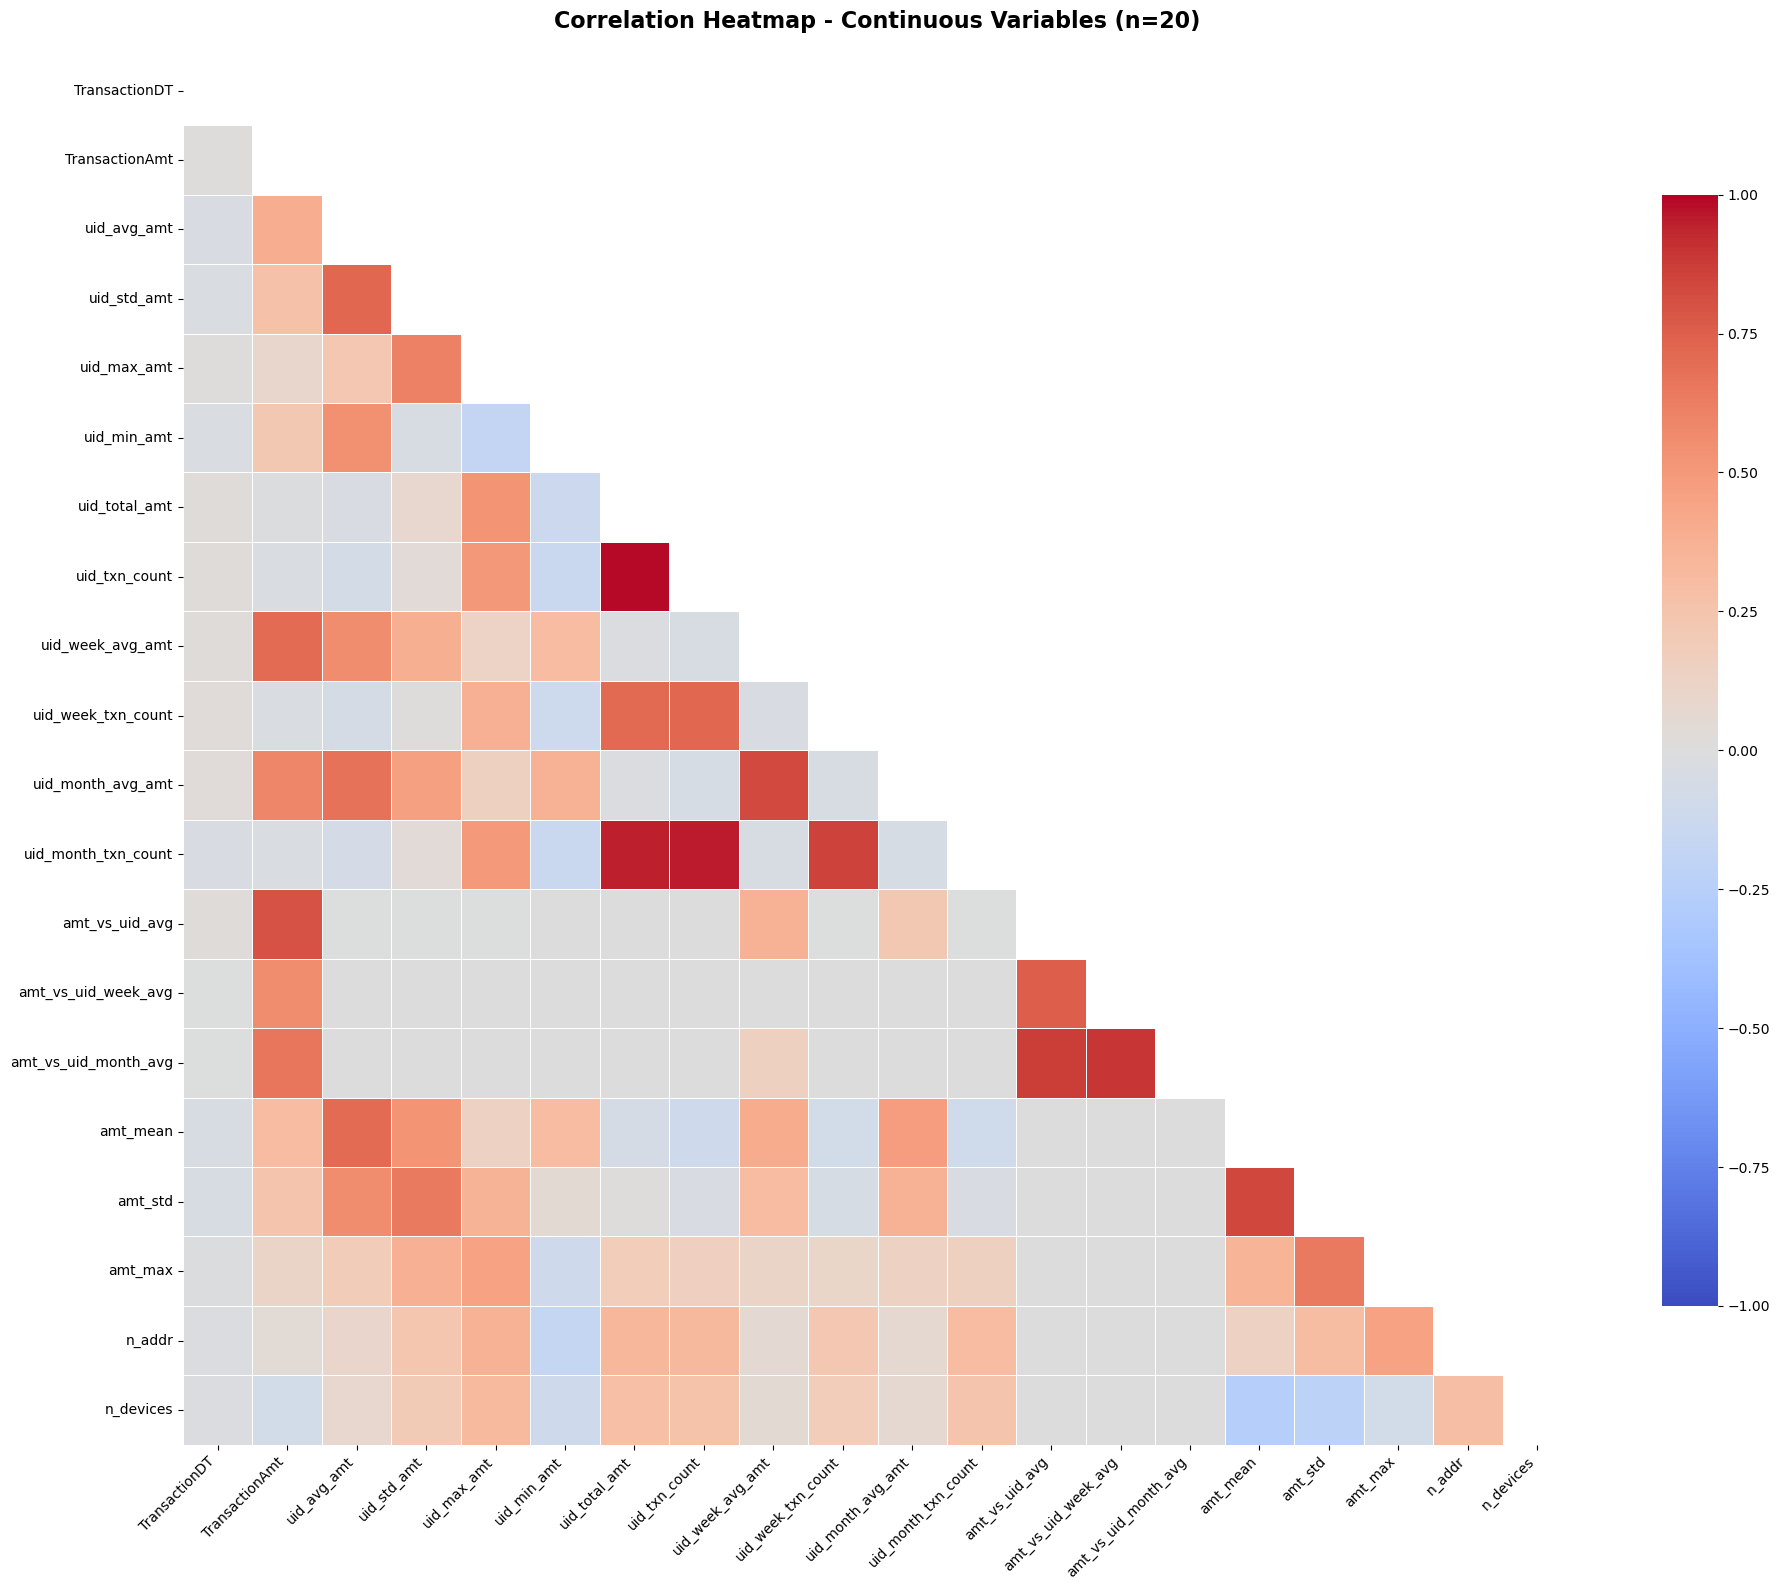


✅ Correlation analysis completed!


In [32]:
# ==================== CORRELATION HEATMAP FOR CONTINUOUS VARIABLES ====================
low_importance_to_drop = []
print("\n" + "="*80)
print("MULTICOLLINEARITY ANALYSIS - CONTINUOUS VARIABLES")
print("="*80)

# Use the same list from previous cell (without suffixes like _1, _2, _3)
# Clean feature names by removing number suffixes
dropped_features = [feat.replace('_1', '').replace('_2', '').replace('_3', '').replace('_freq', '') 
                    for feat in low_importance_to_drop]
dropped_features = list(set(dropped_features))  # Remove duplicates

print(f"Excluding {len(dropped_features)} dropped features from correlation analysis")

# Use other_cols from previous cell (already filtered engineered features)
# Get only continuous numerical columns from the selected features
continuous_cols = []
for col in other_cols:
    # Skip dropped features
    if any(col.startswith(feat) or col == feat for feat in dropped_features):
        continue
    if train_df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        # Check if it's truly continuous (not binary or low cardinality categorical)
        nunique = train_df[col].nunique()
        if nunique > 20:  # More than 20 unique values = continuous
            continuous_cols.append(col)

print(f"\n📊 Found {len(continuous_cols)} continuous variables")
print(f"\nContinuous variables:")
for i, col in enumerate(continuous_cols, 1):
    print(f"  {i:2d}. {col}")

# Calculate correlation matrix
print(f"\n{'='*80}")
print("Calculating correlation matrix...")
print(f"{'='*80}")

corr_matrix = train_df[continuous_cols].corr()

# Find highly correlated pairs (|correlation| > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\n⚠️ HIGH CORRELATION PAIRS (|r| > 0.8): {len(high_corr_pairs)}")
    print("-" * 80)
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        print(f"  {pair['var1']:<35} ↔ {pair['var2']:<35} : {pair['correlation']:>6.3f}")
else:
    print(f"\n✓ No high correlation pairs found (|r| > 0.8)")

# Create correlation heatmap
print(f"\n{'='*80}")
print("Creating correlation heatmap...")
print(f"{'='*80}")

plt.figure(figsize=(20, 16))

# Use mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True if len(continuous_cols) <= 15 else False,  # Annotate only if <= 15 vars
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1, 
    vmax=1
)

plt.title(f'Correlation Heatmap - Continuous Variables (n={len(continuous_cols)})', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n✅ Correlation analysis completed!")
print(f"{'='*80}")

In [ ]:
# ==================== HIGH CORRELATION VERIFICATION ====================
# High correlation feature'lar Feature Selection hücresinde zaten drop edildi.
# Bu hücre sadece doğrulama amaçlı.

print("="*80)
print("HIGH CORRELATION FEATURES - ALREADY DROPPED")
print("="*80)

# Bu feature'lar Feature Selection hücresinde drop edildi:
dropped_high_corr = [
    ('uid_txn_count',       'uid_total_amt',       0.989, 137, 160),
    ('uid_month_txn_count', 'uid_total_amt',       0.945, 133, 160),
    ('uid_week_avg_amt',    'uid_month_avg_amt',   0.833, 106, 123),
    ('amt_vs_uid_week_avg', 'amt_vs_uid_month_avg', 0.894, 77, 88),
    ('amt_vs_uid_avg',      'amt_vs_uid_month_avg', 0.873, 87, 88),
    ('amt_std',             'amt_mean',            0.836, 112, 170),
]

print(f"\n{'Dropped Feature':<25} {'Kept Feature':<25} {'Corr':>6} {'Drop Imp':>10} {'Keep Imp':>10}")
print("-" * 80)
for dropped, kept, corr, drop_imp, keep_imp in dropped_high_corr:
    print(f"{dropped:<25} {kept:<25} {corr:>6.3f} {drop_imp:>10} {keep_imp:>10}")

print(f"\n✅ Total {len(dropped_high_corr)} high-correlation features already dropped in Feature Selection")
print(f"✅ other_cols now has {len(other_cols)} features")
print("="*80)


DROPPING FEATURES WITH HIGH CORRELATION

🔍 Training quick model to determine feature importance...


  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


✅ Feature importance calculated!

  ✓ Dropping: uid_txn_count                  (imp=   137) | Keeping: uid_total_amt                  (imp=   160) | corr=0.989
  ✓ Dropping: uid_month_txn_count            (imp=   133) | Keeping: uid_total_amt                  (imp=   160) | corr=0.945
  ✓ Dropping: amt_vs_uid_week_avg            (imp=    77) | Keeping: amt_vs_uid_month_avg           (imp=    88) | corr=0.894
  ✓ Dropping: amt_vs_uid_avg                 (imp=    87) | Keeping: amt_vs_uid_month_avg           (imp=    88) | corr=0.873
  ✓ Dropping: amt_std                        (imp=   112) | Keeping: amt_mean                       (imp=   170) | corr=0.836
  ✓ Dropping: uid_week_avg_amt               (imp=   106) | Keeping: uid_month_avg_amt              (imp=   123) | corr=0.833

✓ Marked 6 features for exclusion
✓ Updated other_cols list: 36 features remaining

📝 These features will be excluded when creating df_model in next step


In [34]:
# ==================== ENCODING & PREPROCESSING ====================

from sklearn.preprocessing import LabelEncoder

print("\n" + "="*80)
print("ENCODING CATEGORICAL FEATURES")
print("="*80)

# Use updated other_cols list (after dropping high correlation features)
feature_cols = other_cols
df_model = train_df[feature_cols + ['isFraud']].copy()

# Identify categorical columns
categorical_cols = [col for col in feature_cols if df_model[col].dtype in ['object', 'category']]
categorical_high_card = [col for col in categorical_cols if df_model[col].nunique() > 50]

numeric_cols = [col for col in feature_cols if df_model[col].dtype in ['int64', 'float64', 'int32', 'int8', 'int16', 'float32']]
numeric_but_categorical = [col for col in numeric_cols if df_model[col].nunique() < 20]

print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"  - High cardinality (>50): {len(categorical_high_card)}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"  - Numeric but categorical (<20): {len(numeric_but_categorical)}")

# Separate into encoding categories
cat_cols_low = [col for col in categorical_cols if col not in categorical_high_card]
numeric_only = [col for col in numeric_cols if col not in numeric_but_categorical]
numeric_as_cat = numeric_but_categorical
high_card_cols = categorical_high_card

print(f"\n{'='*80}")
print("ENCODING STRATEGY:")
print(f"  - Low cardinality categorical (Label Encoding): {len(cat_cols_low)}")
print(f"  - High cardinality categorical (Frequency Encoding): {len(high_card_cols)}")
print(f"  - Numeric only: {len(numeric_only)}")
print(f"  - Numeric as categorical: {len(numeric_as_cat)}")
print("="*80)

# Label Encoding for low cardinality categoricals
le_dict = {}
for col in cat_cols_low:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f"  ✓ Label Encoded {col}: {len(le.classes_)} unique values")

# Numeric but categorical columns
for col in numeric_as_cat:
    unique_count = df_model[col].nunique()
    if unique_count < 10:
        # One-Hot Encoding
        df_model = pd.get_dummies(df_model, columns=[col], prefix=col, drop_first=True)
        print(f"  ✓ One-Hot Encoded {col}: {unique_count} categories")
    else:
        # Label Encoding
        le = LabelEncoder()
        df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING'})
        df_model[col] = le.fit_transform(df_model[col])
        le_dict[col] = le
        print(f"  ✓ Label Encoded {col}: {unique_count} unique values")

# Frequency Encoding for high cardinality
freq_maps = {}
for col in high_card_cols:
    freq_map = df_model[col].value_counts().to_dict()
    df_model[f'{col}_freq'] = df_model[col].map(freq_map).fillna(0)
    df_model = df_model.drop(col, axis=1)
    freq_maps[col] = freq_map
    print(f"  ✓ Frequency Encoded {col}: {len(freq_map)} unique → {col}_freq")

# Fill missing values in numeric columns
for col in numeric_only:
    if col in df_model.columns and df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(-999)
        print(f"  ✓ Filled NA in {col} with -999")

print(f"\n{'='*80}")
print("Encoding completed!")
print(f"{'='*80}")


ENCODING CATEGORICAL FEATURES

Categorical columns: 13
  - High cardinality (>50): 9
Numeric columns: 22
  - Numeric but categorical (<20): 7

ENCODING STRATEGY:
  - Low cardinality categorical (Label Encoding): 4
  - High cardinality categorical (Frequency Encoding): 9
  - Numeric only: 15
  - Numeric as categorical: 7
  ✓ Label Encoded ProductCD: 5 unique values
  ✓ Label Encoded card4: 5 unique values
  ✓ Label Encoded card6: 5 unique values
  ✓ Label Encoded amt_type: 3 unique values
  ✓ One-Hot Encoded is_round_amount: 2 categories
  ✓ One-Hot Encoded is_psych_amount: 2 categories
  ✓ One-Hot Encoded is_random_amount: 2 categories
  ✓ One-Hot Encoded has_cents: 2 categories
  ✓ One-Hot Encoded is_99_cents: 2 categories
  ✓ One-Hot Encoded is_95_cents: 2 categories
  ✓ One-Hot Encoded is_round_cents: 2 categories
  ✓ Frequency Encoded card1: 17091 unique → card1_freq
  ✓ Frequency Encoded card2: 501 unique → card2_freq
  ✓ Frequency Encoded card3: 133 unique → card3_freq
  ✓ Frequ

# ==================== DROP LOW IMPORTANCE FEATURES (AFTER ENCODING) ====================

print("="*80)
print("DROPPING LOW IMPORTANCE FEATURES (AFTER ENCODING)")
print("="*80)

# These features have low/zero importance based on previous model runs
# They are created during encoding (one-hot encoding adds _1, _2 suffixes)
low_importance_after_encoding = [
    'is_99_cents_1',
    'has_cents_1',
    'multi_card_risk_score_3',
    'multi_card_risk_score_2',
    'multi_card_risk_score_1',
    'is_random_amount_1',
    'is_psych_amount_1',
    'is_95_cents_1',
    'is_round_amount_1',
    'is_multi_card_family_1',
    'is_multi_card_email_addr_1',
    'is_multi_card_device_addr_1',
    'ea_is_new_1',
    'da_is_new_1',
    'identity_device_addr_freq',  # High cardinality freq encoding
    'addr2_freq'  # High cardinality freq encoding
]

# Check which columns exist in df_model
existing_cols = [col for col in low_importance_after_encoding if col in df_model.columns]
missing_cols = [col for col in low_importance_after_encoding if col not in df_model.columns]

print(f"\n📋 Features to drop: {len(low_importance_after_encoding)}")
print(f"✓ Found in df_model: {len(existing_cols)}")
print(f"⚠️ Not found: {len(missing_cols)}")

if existing_cols:
    print(f"\n🗑️ Dropping {len(existing_cols)} features:")
    for col in existing_cols:
        print(f"  - {col}")
    
    df_model = df_model.drop(columns=existing_cols)
    print(f"\n✅ Successfully dropped {len(existing_cols)} low importance features")
else:
    print(f"\n⚠️ No features found to drop")

if missing_cols:
    print(f"\n📝 Features not found (may have been renamed/dropped):")
    for col in missing_cols[:5]:  # Show first 5
        print(f"  - {col}")
    if len(missing_cols) > 5:
        print(f"  ... and {len(missing_cols)-5} more")

print(f"\n{'='*80}")
print(f"df_model shape after dropping: {df_model.shape}")
print(f"{'='*80}")

In [35]:
# ==================== PREPARE X and y ====================

y = df_model['isFraud']
X = df_model.drop(['isFraud'], axis=1)

# Remove TransactionDT for modeling (time leakage)
time_col = 'TransactionDT'
if time_col in X.columns:
    X = X.drop([time_col], axis=1)
    print(f"✓ Dropped {time_col} for modeling (time leakage)")

print(f"\n{'='*80}")
print(f"FINAL X AND Y")
print(f"{'='*80}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Fraud rate: {y.mean()*100:.2f}%")
print(f"\nFeatures used: {X.shape[1]}")

✓ Dropped TransactionDT for modeling (time leakage)

FINAL X AND Y
X shape: (590540, 37)
y shape: (590540,)
Fraud rate: 3.50%

Features used: 37


In [36]:
# ==================== MODEL TRAINING ====================

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve
from lightgbm import LGBMClassifier

print("\n" + "="*80)
print("CROSS VALIDATION (TimeSeriesSplit)")
print("="*80)

model_cv = LGBMClassifier(n_estimators=1000, learning_rate=0.01, verbose=-1, n_jobs=-1)

scores = cross_val_score(
    model_cv, 
    X, 
    y, 
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1
)

print(f"CV AUC: {scores.mean():.6f} (+/- {scores.std():.6f})")
print(f"CV Scores per fold: {[f'{s:.4f}' for s in scores]}")

# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n{'='*80}")
print(f"Train size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val size: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Fraud rate - Train: {y_train.mean()*100:.2f}%, Val: {y_val.mean()*100:.2f}%")

# Train LightGBM
print(f"\n{'='*80}")
print("Training LightGBM model...")
print("="*80)

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    class_weight='balanced',
    verbose=-1,
    n_jobs=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc'
)

# Predictions & Metrics
y_train_pred_proba = lgbm_model.predict_proba(X_train)[:, 1]
y_val_pred_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = lgbm_model.predict(X_val)

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"\n{'='*80}")
print(f"MODEL RESULTS - ADVANCED FEATURES")
print(f"{'='*80}")
print(f"🎯 CV ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"🎯 Train ROC-AUC: {train_auc:.4f}")
print(f"🎯 Val ROC-AUC: {val_auc:.4f}")
print(f"   Val Precision: {precision:.4f}")
print(f"   Val Recall: {recall:.4f}")
print(f"   Val F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
print(f"\nConfusion Matrix:")
print(cm)


CROSS VALIDATION (TimeSeriesSplit)
CV AUC: 0.852334 (+/- 0.022335)
CV Scores per fold: ['0.8094', '0.8713', '0.8562', '0.8686', '0.8562']

Train size: 472,432 (80.0%)
Val size: 118,108 (20.0%)
Fraud rate - Train: 3.50%, Val: 3.50%

Training LightGBM model...

MODEL RESULTS - ADVANCED FEATURES
🎯 CV ROC-AUC: 0.8523 (+/- 0.0223)
🎯 Train ROC-AUC: 0.9435
🎯 Val ROC-AUC: 0.9229
   Val Precision: 0.1803
   Val Recall: 0.8432
   Val F1-Score: 0.2971

Confusion Matrix:
[[98131 15844]
 [  648  3485]]


In [37]:
 #==================== FEATURE IMPORTANCE ====================

feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

# Calculate importance percentage
total_importance = feature_importance['importance'].sum()
feature_importance['importance_pct'] = (feature_importance['importance'] / total_importance) * 100

print(f"\n{'='*80}")
print("FEATURE IMPORTANCE - TOP 30")
print(f"{'='*80}")

for idx, row in feature_importance.head(30).iterrows():
    pct = row['importance_pct']
    bar = '█' * int(pct * 2)  # Visual bar
    print(f"{row['feature']:<35}: {row['importance']:>8,.0f} ({pct:>5.2f}%) {bar}")

print(f"\n{'='*80}")
print(f"Top 10 contribute: {feature_importance.head(10)['importance_pct'].sum():.1f}%")
print(f"Top 20 contribute: {feature_importance.head(20)['importance_pct'].sum():.1f}%")
print(f"Top 30 contribute: {feature_importance.head(30)['importance_pct'].sum():.1f}%")
print(f"Top 40 contribute: {feature_importance.head(40)['importance_pct'].sum():.1f}%")
print(f"Top 50 contribute: {feature_importance.head(50)['importance_pct'].sum():.1f}%")
print(f"Top 60 contribute: {feature_importance.head(60)['importance_pct'].sum():.1f}%")
print(f"Top 65 contribute: {feature_importance.head(65)['importance_pct'].sum():.1f}%")



print(f"{'='*80}")


FEATURE IMPORTANCE - TOP 30
user_anchor_D1                     :    2,297 (15.31%) ██████████████████████████████
TransactionAmt                     :      936 ( 6.24%) ████████████
amt_mean                           :      673 ( 4.49%) ████████
P_emaildomain_freq                 :      646 ( 4.31%) ████████
card2_freq                         :      646 ( 4.31%) ████████
addr1_freq                         :      623 ( 4.15%) ████████
amt_max                            :      598 ( 3.99%) ███████
uid_avg_amt                        :      575 ( 3.83%) ███████
uid_card1_addr1_freq               :      571 ( 3.81%) ███████
uid_week_txn_count                 :      567 ( 3.78%) ███████
uid_max_amt                        :      553 ( 3.69%) ███████
uid_std_amt                        :      552 ( 3.68%) ███████
dist1                              :      549 ( 3.66%) ███████
uid_total_amt                      :      544 ( 3.63%) ███████
uid_min_amt                        :      519 ( 3.46%) ██

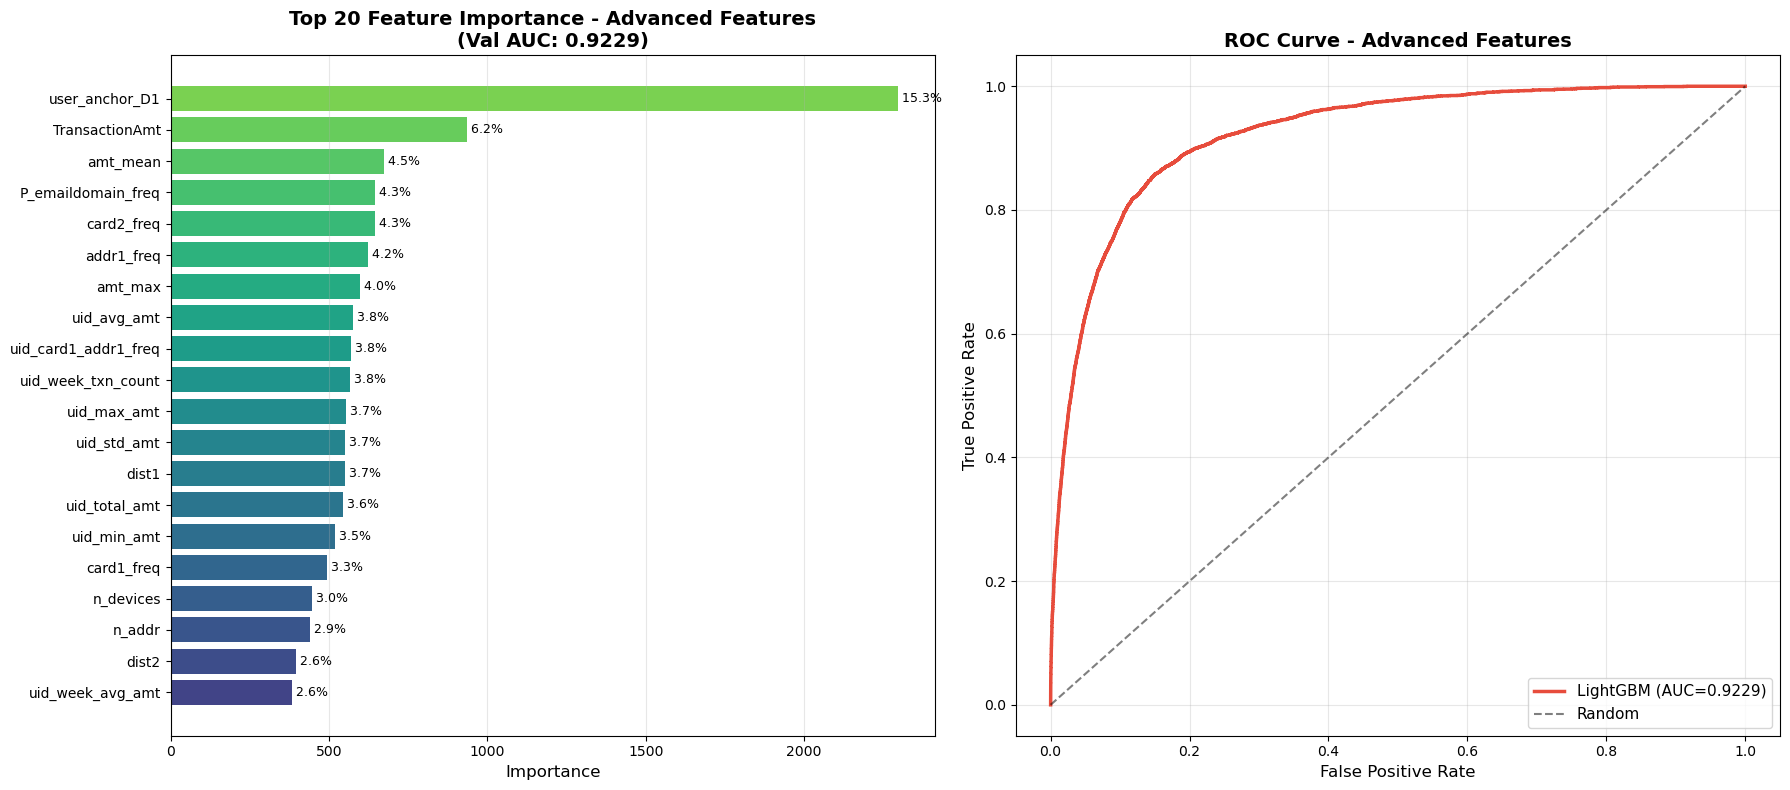


✅ Visualization completed!


In [39]:
# ==================== VISUALIZATION ====================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Feature Importance (Top 20)
ax1 = axes[0]
top_20_features = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(top_20_features)))
bars = ax1.barh(range(len(top_20_features)), top_20_features['importance'], color=colors)
ax1.set_yticks(range(len(top_20_features)))
ax1.set_yticklabels(top_20_features['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title(f'Top 20 Feature Importance - Advanced Features\n(Val AUC: {val_auc:.4f})', 
              fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3, axis='x')

# Add percentage labels
for i, (idx, row) in enumerate(top_20_features.iterrows()):
    ax1.text(row['importance'], i, f" {row['importance_pct']:.1f}%", 
             va='center', fontsize=9, color='black')

# ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'LightGBM (AUC={val_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve - Advanced Features', fontweight='bold', fontsize=14)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("✅ Visualization completed!")
print(f"{'='*80}")

In [40]:
# ==================== LOW IMPORTANCE ANALYSIS ====================

# Find features with very low importance (<0.1%)
very_low_importance = feature_importance[feature_importance['importance_pct'] < 0.1]['feature'].tolist()
zero_importance = feature_importance[feature_importance['importance'] == 0]['feature'].tolist()

print("="*80)
print("LOW IMPORTANCE FEATURE ANALYSIS")
print("="*80)

print(f"\n❌ Zero Importance Features ({len(zero_importance)}):")
for feat in zero_importance[:10]:
    print(f"  - {feat}")
if len(zero_importance) > 10:
    print(f"  ... and {len(zero_importance)-10} more")

print(f"\n⚠️ Very Low Importance Features (<0.1%) ({len(very_low_importance)}):")
for feat in very_low_importance[:15]:
    imp_pct = feature_importance[feature_importance['feature'] == feat]['importance_pct'].values[0]
    print(f"  - {feat}: {imp_pct:.3f}%")
if len(very_low_importance) > 15:
    print(f"  ... and {len(very_low_importance)-15} more")

print(f"\n{'='*80}")
print(f"💡 Recommendation: Consider dropping {len(zero_importance) + len(very_low_importance)} low-value features")
print(f"{'='*80}")

LOW IMPORTANCE FEATURE ANALYSIS

❌ Zero Importance Features (3):
  - has_cents_1
  - is_psych_amount_1
  - is_round_amount_1

⚠️ Very Low Importance Features (<0.1%) (4):
  - addr2_freq: 0.053%
  - has_cents_1: 0.000%
  - is_psych_amount_1: 0.000%
  - is_round_amount_1: 0.000%

💡 Recommendation: Consider dropping 7 low-value features
